# RMF_Net Checkpoint Visualization

Load the saved `net` checkpoint, run the Abilene test split, restore predictions to raw target values, and plot true vs. predicted curves.

In [1]:
from pathlib import Path
import os
import re
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent

os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CHECKPOINT = ROOT / "checkpoints" / "net" / "Datasetwater_batchsize64_Modelnet_dmodel64_epochs200_patience40_SeqLen96_PredLen32_EncIn144_OutDim1_round_0.pt"
assert CHECKPOINT.exists(), CHECKPOINT

print("ROOT:", ROOT)
print("CWD:", Path.cwd())
print("CHECKPOINT:", CHECKPOINT)

ROOT: /home/xuke/mkw/Extreme
CWD: /home/xuke/mkw/Extreme
CHECKPOINT: /home/xuke/mkw/Extreme/checkpoints/net/Datasetwater_batchsize64_Modelnet_dmodel64_epochs200_patience40_SeqLen96_PredLen32_EncIn144_OutDim1_round_0.pt


In [ ]:
from configs.NetConfig import NetConfig
from data_provider.DS_abilene_diff import DS
from exp.exp_model_net_diff import Model


def parse_checkpoint_config(path: Path):
    name = path.name
    patterns = {
        "bs": r"batchsize(\d+)",
        "model": r"Model([^_]+)",
        "d_model": r"dmodel(\d+)",
        "epochs": r"epochs(\d+)",
        "patience": r"patience(\d+)",
        "seq_len": r"SeqLen(\d+)",
        "pred_len": r"PredLen(\d+)",
        "enc_in": r"EncIn(\d+)",
        "out_dim": r"OutDim(\d+)",
    }
    parsed = {}
    for key, pattern in patterns.items():
        match = re.search(pattern, name)
        if match:
            value = match.group(1)
            parsed[key] = value if key == "model" else int(value)
    return parsed


device = "cuda" if torch.cuda.is_available() else "cpu"
parsed = parse_checkpoint_config(CHECKPOINT)

config = NetConfig()
for key, value in parsed.items():
    setattr(config, key, value)

config.model = "net"
config.c_in = config.enc_in
config.dec_in = config.out_dim
config.label_len = 0
config.device = device
config.num_workers = 0
config.data_path = str(ROOT / "datasets" / "Abilene_12_12_3000_T3000_flat144.csv")
config.retrain = False
config.continue_train = False

print(parsed)
print("device:", config.device)
print("data_path:", config.data_path)
print("seq_len/pred_len/enc_in/out_dim:", config.seq_len, config.pred_len, config.enc_in, config.out_dim)

{'bs': 64, 'model': 'net', 'd_model': 64, 'epochs': 200, 'patience': 40, 'seq_len': 96, 'pred_len': 32, 'enc_in': 144, 'out_dim': 1}
device: cuda
data_path: /home/xuke/mkw/Extreme/datasets/Abilene_12_12_3000_T3000_flat144.csv
seq_len/pred_len/enc_in/out_dim: 96 32 144 1


In [3]:
datamodule = DS(config)
model = Model(config).to(config.device)

state = torch.load(CHECKPOINT, map_location=config.device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]

try:
    model.load_state_dict(state, strict=True)
except RuntimeError:
    cleaned = {k.replace("_orig_mod.", "", 1): v for k, v in state.items()}
    model.load_state_dict(cleaned, strict=True)

model.eval()
print("Loaded checkpoint.")

[Tail Threshold] |diff| q90=0.000028
[Raw Threshold] value q90=0.000079, q99=0.000190
[Abilene] raw shape: (3000, 144), T=3000, C=144
[Abilene] split points: train_end=2100, val_end=2400
[Abilene] raw split lengths with context: train=2100, val=396, test=696
[Abilene] windows: x_train=(1973, 96, 144), y_train=(1973, 32, 1) x_val=(269, 96, 144), y_val=(269, 32, 1) x_test=(569, 96, 144), y_test=(569, 32, 1)
[Abilene] many-to-one target: target_col=0, target_dim=1
[Abilene] diff norm mean/std shape: mean=(144,), std=(144,)
Loaded checkpoint.


/tmp/ipykernel_4012932/3456865564.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CHECKPOINT, map_location=config.device)


In [4]:
BUILD_RETRIEVAL_INDEX = True

if BUILD_RETRIEVAL_INDEX and hasattr(model, "prepare_retrieval_index"):
    model.prepare_retrieval_index(
        datamodule.train_data_loader.dataset,
        datamodule.train_data_loader,
    )

preds = []
labels = []
sample_ids_all = []

with torch.no_grad():
    for x, x_mark, label, sample_ids in datamodule.test_data_loader:
        x = x.float().to(config.device)
        x_mark = x_mark.float().to(config.device)
        label = label.float().to(config.device)
        sample_ids = sample_ids.to(config.device).long()

        dec_input = torch.zeros_like(label[:, -config.pred_len:, :]).float()
        dec_input = torch.cat([label[:, :config.label_len, :], dec_input], dim=1)

        output, _ = model(
            x,
            x_mark,
            dec_input,
            None,
            sample_ids,
            mode="test",
        )

        preds.append(output["point_pred"])
        labels.append(label)
        sample_ids_all.append(sample_ids)

preds = torch.cat(preds, dim=0)
labels = torch.cat(labels, dim=0)
sample_ids_all = torch.cat(sample_ids_all, dim=0)

pred_raw, true_raw = model._restore_to_raw(
    preds,
    labels,
    datamodule,
    sample_ids_all,
)

pred_raw_np = pred_raw.detach().cpu().numpy()
true_raw_np = true_raw.detach().cpu().numpy()
sample_ids_np = sample_ids_all.detach().cpu().numpy()

print("preds standardized:", tuple(preds.shape))
print("raw restored:", pred_raw_np.shape, true_raw_np.shape)
print("raw true min/max/mean:", true_raw_np.min(), true_raw_np.max(), true_raw_np.mean())
print("raw pred min/max/mean:", pred_raw_np.min(), pred_raw_np.max(), pred_raw_np.mean())

*******Constructing the Retrieval Indexes*********
*******Finishing the Retrieval Indexes*********
preds standardized: (569, 32, 1)
raw restored: (569, 32, 1) (569, 32, 1)
raw true min/max/mean: -8.913048e-11 0.00034871168 2.217409e-05
raw pred min/max/mean: -5.1151786e-05 0.00042120187 3.467261e-05


In [5]:
def aggregate_by_time(true_raw, pred_raw, sample_ids, seq_len):
    true_raw = np.asarray(true_raw)
    pred_raw = np.asarray(pred_raw)
    sample_ids = np.asarray(sample_ids).astype(np.int64)

    n_windows, pred_len, out_dim = true_raw.shape
    true_sum = {}
    pred_sum = {}
    count = {}

    for window_idx, start in enumerate(sample_ids):
        base = int(start) + int(seq_len)
        for horizon in range(pred_len):
            time_idx = base + horizon
            if time_idx not in count:
                true_sum[time_idx] = np.zeros(out_dim, dtype=np.float64)
                pred_sum[time_idx] = np.zeros(out_dim, dtype=np.float64)
                count[time_idx] = 0
            true_sum[time_idx] += true_raw[window_idx, horizon]
            pred_sum[time_idx] += pred_raw[window_idx, horizon]
            count[time_idx] += 1

    rows = []
    for time_idx in sorted(count):
        rows.append({
            "time_idx": time_idx,
            "count": count[time_idx],
            "true": true_sum[time_idx][0] / count[time_idx],
            "pred": pred_sum[time_idx][0] / count[time_idx],
        })
    return pd.DataFrame(rows)


window_df = pd.DataFrame({
    "index": np.arange(true_raw_np.reshape(-1).shape[0]),
    "true": true_raw_np.reshape(-1),
    "pred": pred_raw_np.reshape(-1),
})

agg_df = aggregate_by_time(true_raw_np, pred_raw_np, sample_ids_np, config.seq_len)

test_context_len = len(datamodule.test_data_loader.dataset) * 1
flattened_points = true_raw_np.size
unique_time_points = len(agg_df)
first_time_idx = int(agg_df["time_idx"].iloc[0]) if len(agg_df) > 0 else None
last_time_idx = int(agg_df["time_idx"].iloc[-1]) if len(agg_df) > 0 else None

mae = np.mean(np.abs(window_df["pred"].to_numpy() - window_df["true"].to_numpy()))
rmse = np.sqrt(np.mean((window_df["pred"].to_numpy() - window_df["true"].to_numpy()) ** 2))

print("test loader windows:", len(datamodule.test_data_loader.dataset))
print("flattened window points:", flattened_points)
print("aggregated unique time points:", unique_time_points)
print("aggregated time range:", first_time_idx, "->", last_time_idx)
print("MAE:", mae, "RMSE:", rmse)
display(window_df.head())
display(agg_df.head())

test loader windows: 569
flattened window points: 18208
aggregated unique time points: 600
aggregated time range: 2400 -> 2999
MAE: 3.9186994e-05 RMSE: 6.0550203e-05


,index,true,pred
0,0,0.000000,-0.000006
1,1,0.000000,-0.000026
2,2,0.000000,-0.000037
3,3,0.000034,-0.000030
4,4,0.000000,-0.000032


,time_idx,count,true,pred
0,2400,1,0.000000,-0.000006
1,2401,2,0.000000,-0.000017
2,2402,3,0.000000,-0.000021
3,2403,4,0.000034,-0.000017
4,2404,5,0.000000,-0.000012


plot style: seaborn-v0_8-whitegrid


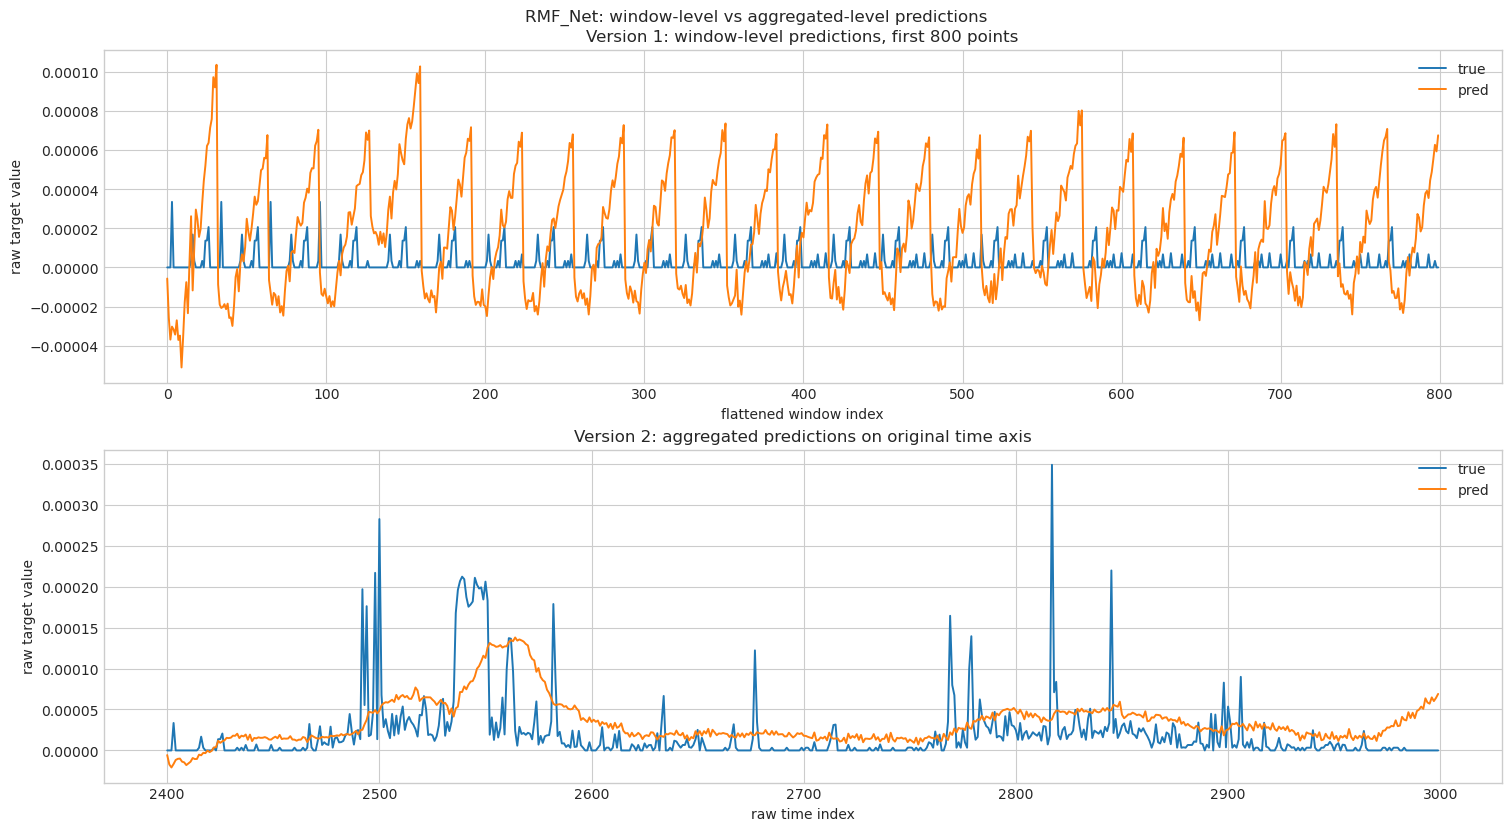

In [6]:
for style_name in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot", "default"]:
    if style_name in plt.style.available or style_name == "default":
        plt.style.use(style_name)
        print("plot style:", style_name)
        break


max_window_points = min(800, len(window_df))
fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)
fig.suptitle("RMF_Net: window-level vs aggregated-level predictions", y=1.02)

axes[0].plot(window_df["index"].iloc[:max_window_points], window_df["true"].iloc[:max_window_points], label="true", linewidth=1.4)
axes[0].plot(window_df["index"].iloc[:max_window_points], window_df["pred"].iloc[:max_window_points], label="pred", linewidth=1.4)
axes[0].set_title(f"Version 1: window-level predictions, first {max_window_points} points")
axes[0].set_xlabel("flattened window index")
axes[0].set_ylabel("raw target value")
axes[0].legend()

axes[1].plot(agg_df["time_idx"], agg_df["true"], label="true", linewidth=1.4)
axes[1].plot(agg_df["time_idx"], agg_df["pred"], label="pred", linewidth=1.4)
axes[1].set_title("Version 2: aggregated predictions on original time axis")
axes[1].set_xlabel("raw time index")
axes[1].set_ylabel("raw target value")
axes[1].legend()

plt.show()

In [7]:
OUT_DIR = ROOT / "draw"
OUT_DIR.mkdir(exist_ok=True)

window_path = OUT_DIR / "checkpoint_net_PL5_window_plot_data.csv"
agg_path = OUT_DIR / "checkpoint_net_PL5_agg_plot_data.csv"

window_df.to_csv(window_path, index=False)
agg_df.to_csv(agg_path, index=False)

print("saved:", window_path)
print("saved:", agg_path)

saved: /home/xuke/mkw/Extreme/draw/checkpoint_net_PL5_window_plot_data.csv
saved: /home/xuke/mkw/Extreme/draw/checkpoint_net_PL5_agg_plot_data.csv
